IMPORTANDO BIBLIOTECAS


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.decomposition import PCA

from sklearn.metrics import (
    silhouette_score,
    calinski_harabasz_score,
    davies_bouldin_score,
    adjusted_rand_score,
    normalized_mutual_info_score
)

from scipy.cluster.hierarchy import linkage, dendrogram
from scipy.spatial.distance import squareform

In [3]:
from pathlib import Path


caminhos = [
    Path('../5_Tabelas_e_Dados/df_macro_agosto2026.csv'),
    Path('Entrega_Classroom/5_Tabelas_e_Dados/df_macro_agosto2026.csv'),
]
caminho_base = next((c for c in caminhos if c.is_file()), None)
if caminho_base is None:
    raise FileNotFoundError('Base não encontrada. Verifique a pasta de execução do notebook.')

df = pd.read_csv(caminho_base, parse_dates=['Date'])
print(f'Base carregada: {df.shape[0]} registros e {df.shape[1]} colunas')
display(df.head())

Base carregada: 174 registros e 30 colunas


,Date,IPCA,IPCA_Transportes,IPCA Alimentação_bebidas,INPC_Habitação,IPCA_Saúde_cuidados_pessoais,IPCA_Vestuário,IPCA_Educação,IPCA_Despesas_Pessoais,USDBRL,...,Produção_Derivados_Petróleo,Consumo_Gasolina,Consumo_Óleo_Combustível,Consumo_Energia_Comercial,Consumo_Energia_Residencial,Consumo_Energia_Total,Estoque_Empregos_Formais_Total,Estoque_Empregos_Formais_Agropecuária,Estoque_Empregos_Formais_Construção,Regime_Inflacao
0,2012-03-01,-0.08,0.16,0.25,0.48,0.38,-0.61,0.54,0.55,1.8221,...,2169.0,537.0,59.0,7037.0,10271.0,38636.0,37448659.0,1449352.0,2921256.0,Deflação
1,2012-04-01,0.55,0.10,0.51,0.80,0.96,0.98,0.04,2.23,1.8918,...,2106.0,531.0,64.0,6856.0,9928.0,37996.0,37712269.0,1474134.0,2973494.0,Alta / Acima da Meta
2,2012-05-01,0.48,-0.58,0.73,0.80,0.66,0.89,-0.01,0.60,2.0223,...,2136.0,527.0,61.0,6417.0,9532.0,36810.0,37908043.0,1527775.0,2999515.0,Meta / Estável
3,2012-06-01,-0.31,-1.18,0.68,0.28,0.38,0.39,0.06,0.47,2.0213,...,2127.0,538.0,58.0,6282.0,9605.0,36528.0,38071270.0,1592790.0,3010840.0,Deflação
4,2012-07-01,0.06,-0.03,0.91,0.54,0.36,0.04,0.12,0.91,2.0499,...,2116.0,527.0,62.0,6033.0,9274.0,35917.0,38255266.0,1620105.0,3044862.0,Meta / Estável


## Experimento A variaveis macroeconomicas

Base com indicadores macroeconomicos. IPCA geral, regime de inflacao e componentes setoriais de precos ficam fora. A data permanece apenas como indice.


In [4]:
# Componentes do IPCA presentes na base.
componentes_ipca = [
    coluna for coluna in df.columns
    if coluna.startswith('IPCA_') or coluna.startswith('IPCA ')
]

# INPC_... e um componente setorial de outro indice; nao entra em A nem em B.
colunas_excluidas = {'IPCA', 'Regime_Inflacao', *componentes_ipca}
colunas_macro = [
    coluna for coluna in df.select_dtypes(include='number').columns
    if coluna not in colunas_excluidas and not coluna.startswith('INPC_')
]

base_a = df.set_index('Date')[colunas_macro].copy()
print(f'Experimento A: {base_a.shape[0]} meses e {base_a.shape[1]} variaveis macroeconomicas')
print(base_a.columns.tolist())


Experimento A: 174 meses e 20 variaveis macroeconomicas
['USDBRL', 'Reservas Internacionais', 'Desemprego', 'SELIC', 'SalMinimo', 'PIB Mensal', 'QteOvos', 'INPC', 'IGP_M', 'IGP_DI', 'IPC_BR', 'Produção_Derivados_Petróleo', 'Consumo_Gasolina', 'Consumo_Óleo_Combustível', 'Consumo_Energia_Comercial', 'Consumo_Energia_Residencial', 'Consumo_Energia_Total', 'Estoque_Empregos_Formais_Total', 'Estoque_Empregos_Formais_Agropecuária', 'Estoque_Empregos_Formais_Construção']


### Correlacao e reducao de redundancia em A

Uma correlacao alta entre niveis pode aparecer apenas porque duas series crescem ao longo do tempo. Por isso, retiramos uma coluna somente quando a correlacao absoluta e pelo menos 0,90 nos niveis **e** 0,70 nas variacoes mensais. Entre os indicadores de precos, priorizamos IGP_DI; entre os de energia, mantemos a serie residencial em vez do total agregado. A tabela mostra os pares candidatos e a decisao. Os limiares sao criterios exploratorios, nao testes de causalidade.


In [5]:
from itertools import combinations
import pandas as pd

# ==========================================================
# 1. COPIAR A BASE ORIGINAL
# ==========================================================

base_a_original = base_a.copy()


# ==========================================================
# 2. CORRELAÇÃO DOS NÍVEIS
# ==========================================================

corr_niveis_a = base_a_original.corr()


# ==========================================================
# 3. CALCULAR VARIAÇÃO MENSAL
# ==========================================================

variacoes_a = base_a_original.diff()


# ==========================================================
# 4. CORRELAÇÃO DAS VARIAÇÕES MENSAIS
# ==========================================================

corr_variacoes_a = variacoes_a.corr()


# ==========================================================
# 5. DEFINIR LIMIARES
# ==========================================================

limiar_niveis_a = 0.90
limiar_variacoes_a = 0.70


# ==========================================================
# 6. ANALISAR TODOS OS PARES DE VARIÁVEIS
# ==========================================================

pares_a = []

for primeira, segunda in combinations(base_a_original.columns, 2):

    correlacao_nivel = corr_niveis_a.loc[primeira, segunda]
    correlacao_variacao = corr_variacoes_a.loc[primeira, segunda]

    if abs(correlacao_nivel) >= limiar_niveis_a:

        redundante = (
            abs(correlacao_variacao) >= limiar_variacoes_a
        )

        pares_a.append({
            "variavel_1": primeira,
            "variavel_2": segunda,
            "corr_nivel": correlacao_nivel,
            "corr_variacao_mensal": correlacao_variacao,
            "redundante_pelo_criterio": redundante,
        })


# ==========================================================
# 7. TRANSFORMAR RESULTADO EM DATAFRAME
# ==========================================================

pares_a_df = pd.DataFrame(pares_a)

if not pares_a_df.empty:

    pares_a_df = pares_a_df.sort_values(
        "corr_nivel",
        key=lambda s: s.abs(),
        ascending=False
    )


# ==========================================================
# 8. DEFINIR PRIORIDADE DAS VARIÁVEIS
# ==========================================================

prioridade_a = [
    "IGP_DI",
    "Consumo_Energia_Residencial"
]

ordem_a = prioridade_a + [
    coluna
    for coluna in base_a_original.columns
    if coluna not in prioridade_a
]


# ==========================================================
# 9. DECIDIR QUAIS VARIÁVEIS MANTER
# ==========================================================

mantidas_a = []
remocoes_a = []

for coluna in ordem_a:

    semelhante = next(
        (
            mantida
            for mantida in mantidas_a
            if abs(corr_niveis_a.loc[coluna, mantida])
            >= limiar_niveis_a
            and abs(corr_variacoes_a.loc[coluna, mantida])
            >= limiar_variacoes_a
        ),
        None
    )

    if semelhante is None:

        mantidas_a.append(coluna)

    else:

        remocoes_a.append({
            "removida": coluna,
            "mantida": semelhante
        })


# ==========================================================
# 10. CRIAR BASE REDUZIDA
# ==========================================================

colunas_remover = [
    item["removida"]
    for item in remocoes_a
]

base_a = base_a_original.drop(
    columns=colunas_remover
)

### Padronizacao e PCA para visualizacao de A

Depois da reducao de redundancia, o `StandardScaler` coloca as variaveis na mesma escala. O PCA projeta os 18 indicadores em dois eixos apenas para visualizar os meses. `base_a` continua com as variaveis originais selecionadas; `base_a_padronizada` fica disponivel para a clusterizacao futura.


Variancia explicada por PC1: 49.7%
Variancia explicada por PC2: 18.9%
Variancia acumulada nos dois eixos: 68.6%


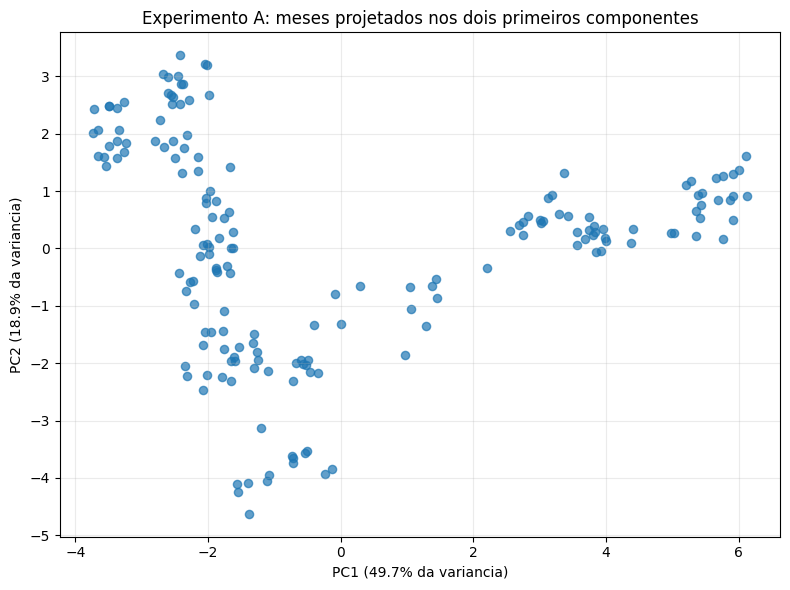

In [6]:
# Padronizar somente as colunas que permaneceram no experimento A.
scaler_a = StandardScaler()
base_a_padronizada = pd.DataFrame(
    scaler_a.fit_transform(base_a),
    index=base_a.index,
    columns=base_a.columns,
)

# Projetar em duas dimensoes para inspecao visual.
pca_a = PCA(n_components=2)
coordenadas_a = pca_a.fit_transform(base_a_padronizada)
projecao_a = pd.DataFrame(
    coordenadas_a,
    index=base_a.index,
    columns=['PC1', 'PC2'],
)

variancia_a = pca_a.explained_variance_ratio_
print(f'Variancia explicada por PC1: {variancia_a[0]:.1%}')
print(f'Variancia explicada por PC2: {variancia_a[1]:.1%}')
print(f'Variancia acumulada nos dois eixos: {variancia_a.sum():.1%}')

fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(projecao_a['PC1'], projecao_a['PC2'], alpha=0.7, s=35)
ax.set_xlabel(f'PC1 ({variancia_a[0]:.1%} da variancia)')
ax.set_ylabel(f'PC2 ({variancia_a[1]:.1%} da variancia)')
ax.set_title('Experimento A: meses projetados nos dois primeiros componentes')
ax.grid(alpha=0.25)
plt.tight_layout()
plt.show()


### Funções de apoio para comparar os métodos

Todas as métricas internas são calculadas no espaço completo padronizado. A projeção PCA de duas dimensões serve apenas para visualização. IPCA e Regime_Inflacao são usados somente depois de os grupos terem sido formados.

In [7]:
def avaliar_kmeans(base_padronizada, valores_k=range(2, 7)):
    linhas = []
    for k in valores_k:
        modelo = KMeans(n_clusters=k, random_state=42, n_init=50)
        grupos = modelo.fit_predict(base_padronizada)
        linhas.append({
            "k": k,
            "inercia": modelo.inertia_,
            "silhouette": silhouette_score(base_padronizada, grupos),
            "calinski_harabasz": calinski_harabasz_score(base_padronizada, grupos),
            "davies_bouldin": davies_bouldin_score(base_padronizada, grupos),
        })
    return pd.DataFrame(linhas)


def avaliar_hierarquico(base_padronizada, valores_k=range(2, 7)):
    linhas = []
    for k in valores_k:
        grupos = AgglomerativeClustering(n_clusters=k, linkage="ward").fit_predict(base_padronizada)
        linhas.append({
            "k": k,
            "silhouette": silhouette_score(base_padronizada, grupos),
            "calinski_harabasz": calinski_harabasz_score(base_padronizada, grupos),
            "davies_bouldin": davies_bouldin_score(base_padronizada, grupos),
        })
    return pd.DataFrame(linhas)


def grafico_metrica(tabela, coluna, titulo, rotulo):
    fig, ax = plt.subplots(figsize=(7, 4))
    ax.plot(tabela["k"], tabela[coluna], marker="o")
    ax.set_xticks(tabela["k"])
    ax.set_xlabel("Número de clusters (k)")
    ax.set_ylabel(rotulo)
    ax.set_title(titulo)
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()


def grafico_pca_grupos(projecao, grupos, titulo, centroides=None):
    fig, ax = plt.subplots(figsize=(8, 6))
    grupos = np.asarray(grupos)
    for grupo in np.unique(grupos):
        pontos = projecao.iloc[np.flatnonzero(grupos == grupo)]
        ax.scatter(pontos["PC1"], pontos["PC2"], alpha=0.75, s=35, label=str(grupo))
    if centroides is not None:
        ax.scatter(centroides[:, 0], centroides[:, 1], marker="X",
                   s=180, c="black", edgecolors="white", label="Centroides")
    ax.set(xlabel="PC1", ylabel="PC2", title=titulo)
    ax.legend(title="Grupo", bbox_to_anchor=(1.02, 1), loc="upper left")
    ax.grid(alpha=0.25)
    plt.tight_layout()
    plt.show()


def tabelas_regime(regime, grupos):
    contagens = pd.crosstab(regime, grupos, rownames=["Regime_Inflacao"],
                           colnames=["Cluster"])
    percentuais = pd.crosstab(regime, grupos, normalize="columns",
                              rownames=["Regime_Inflacao"],
                              colnames=["Cluster"]).mul(100)
    display(contagens)
    display(percentuais.round(1))
    return contagens, percentuais


def perfis_cluster(base_original, base_padronizada, grupos, nome):
    grupos = pd.Series(np.asarray(grupos), index=base_original.index, name="Cluster")
    medias = base_original.groupby(grupos).mean()
    medianas = base_original.groupby(grupos).median()
    medias_padronizadas = base_padronizada.groupby(grupos).mean()
    print(f"{nome}: médias das variáveis originais")
    display(medias.round(2))
    print(f"{nome}: medianas das variáveis originais")
    display(medianas.round(2))
    print(f"{nome}: médias padronizadas")
    display(medias_padronizadas.round(2))
    fig, ax = plt.subplots(figsize=(max(10, len(base_original.columns) * 0.55), 3 + len(medias)))
    im = ax.imshow(medias_padronizadas, cmap="coolwarm", vmin=-2, vmax=2, aspect="auto")
    ax.set_xticks(range(len(medias_padronizadas.columns)), medias_padronizadas.columns,
                  rotation=65, ha="right")
    ax.set_yticks(range(len(medias_padronizadas.index)), medias_padronizadas.index)
    ax.set(xlabel="Variáveis", ylabel="Cluster", title=f"{nome}: perfil padronizado")
    fig.colorbar(im, ax=ax, label="Média em desvios-padrão")
    plt.tight_layout()
    plt.show()
    return medias, medianas, medias_padronizadas


def grafico_temporal(indice, grupos, titulo):
    fig, ax = plt.subplots(figsize=(12, 3.5))
    grupos = np.asarray(grupos)
    for grupo in np.unique(grupos):
        mascara = grupos == grupo
        ax.scatter(indice[mascara], grupos[mascara], s=30, label=str(grupo))
    ax.set_yticks(np.unique(grupos))
    ax.set(xlabel="Mês", ylabel="Cluster", title=titulo)
    ax.legend(title="Cluster", bbox_to_anchor=(1.02, 1), loc="upper left")
    ax.grid(axis="x", alpha=0.25)
    plt.tight_layout()
    plt.show()


def casos_divergentes(base_original, referencia, grupos):
    grupos = pd.Series(np.asarray(grupos), index=base_original.index, name="Cluster")
    tabela = pd.crosstab(grupos, referencia["Regime_Inflacao"])
    predominante = tabela.idxmax(axis=1)
    indicadores = [c for c in ["USDBRL", "IGP_DI", "SELIC", "Desemprego"]
                   if c in base_original.columns]
    if not indicadores:
        indicadores = list(base_original.columns[:4])
    casos = referencia[["Regime_Inflacao", "IPCA"]].copy()
    casos["Cluster"] = grupos
    casos["Regime_predominante_no_cluster"] = grupos.map(predominante)
    casos = casos.join(base_original[indicadores])
    casos = casos[casos["Regime_Inflacao"] != casos["Regime_predominante_no_cluster"]]
    exemplos = casos.groupby("Regime_Inflacao", sort=False).head(3)
    display(exemplos.round(2))
    return casos


def resumo_modelos(kmeans_resultado, hier_resultado, k_kmeans, k_hier,
                   grupos_kmeans, grupos_hier, regime):
    linha_k = kmeans_resultado.set_index("k").loc[k_kmeans]
    linha_h = hier_resultado.set_index("k").loc[k_hier]
    tabela = pd.DataFrame([
        {"Modelo": "K-means", "K": k_kmeans,
         "Silhouette": linha_k["silhouette"],
         "Calinski_Harabasz": linha_k["calinski_harabasz"],
         "Davies_Bouldin": linha_k["davies_bouldin"],
         "ARI_Regime": adjusted_rand_score(regime, grupos_kmeans),
         "NMI_Regime": normalized_mutual_info_score(regime, grupos_kmeans)},
        {"Modelo": "Hierárquico Ward", "K": k_hier,
         "Silhouette": linha_h["silhouette"],
         "Calinski_Harabasz": linha_h["calinski_harabasz"],
         "Davies_Bouldin": linha_h["davies_bouldin"],
         "ARI_Regime": adjusted_rand_score(regime, grupos_hier),
         "NMI_Regime": normalized_mutual_info_score(regime, grupos_hier)},
    ])
    return tabela

### A1. PCA completo e contribuição das variáveis

O PCA de duas dimensões já criado permanece apenas como projeção. Aqui o PCA completo informa quanta variação cada componente representa. Os pesos abaixo mostram quais variáveis mais aparecem em PC1 e PC2; eles não indicam causalidade.

,Componente,Variancia_Explicada,Variancia_Acumulada
0,1,0.4966,0.4966
1,2,0.1890,0.6856
2,3,0.1248,0.8104
3,4,0.0482,0.8586
4,5,0.0419,0.9005
5,6,0.0252,0.9257
6,7,0.0222,0.9478
7,8,0.0188,0.9666
8,9,0.0122,0.9789
9,10,0.0074,0.9862


80% da variância: 3 componentes
90% da variância: 5 componentes


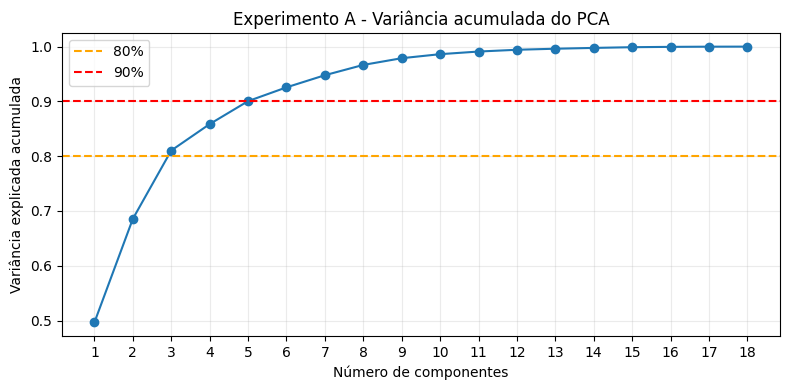

,variavel,PC1,PC2,importancia
2,Desemprego,-0.146,-0.446,0.592
17,Estoque_Empregos_Formais_Construção,0.103,0.449,0.552
0,USDBRL,0.265,-0.280,0.545
11,Consumo_Gasolina,0.139,0.389,0.528
12,Consumo_Óleo_Combustível,-0.234,0.282,0.516
3,SELIC,0.151,0.350,0.501
6,QteOvos,0.308,-0.186,0.493
15,Estoque_Empregos_Formais_Total,0.310,0.175,0.484
4,SalMinimo,0.323,-0.120,0.443
10,Produção_Derivados_Petróleo,0.311,-0.111,0.421


In [8]:
pca_completo_a = PCA().fit(base_a_padronizada)
variancia_exp_a = pca_completo_a.explained_variance_ratio_
variancia_acum_a = np.cumsum(variancia_exp_a)
resultado_pca_a = pd.DataFrame({
    "Componente": np.arange(1, len(variancia_exp_a) + 1),
    "Variancia_Explicada": variancia_exp_a,
    "Variancia_Acumulada": variancia_acum_a,
})
componentes_80_a = int(np.searchsorted(variancia_acum_a, 0.80) + 1)
componentes_90_a = int(np.searchsorted(variancia_acum_a, 0.90) + 1)
display(resultado_pca_a.round(4))
print(f"80% da variância: {componentes_80_a} componentes")
print(f"90% da variância: {componentes_90_a} componentes")
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(resultado_pca_a["Componente"], resultado_pca_a["Variancia_Acumulada"],
        marker="o")
ax.axhline(0.80, color="orange", linestyle="--", label="80%")
ax.axhline(0.90, color="red", linestyle="--", label="90%")
ax.set_xticks(resultado_pca_a["Componente"])
ax.set(xlabel="Número de componentes", ylabel="Variância explicada acumulada",
       title="Experimento A - Variância acumulada do PCA")
ax.legend()
ax.grid(alpha=0.25)
plt.tight_layout()
plt.show()

loadings_a = pd.DataFrame({
    "variavel": base_a_padronizada.columns,
    "PC1": pca_a.components_[0],
    "PC2": pca_a.components_[1],
})
loadings_a["importancia"] = loadings_a["PC1"].abs() + loadings_a["PC2"].abs()
loadings_a = loadings_a.sort_values("importancia", ascending=False)
display(loadings_a.round(3))

### A2. K-means: testar k de 2 a 6

Os modelos usam as 18 variáveis de base_a_padronizada. O PCA 2D não participa do ajuste.

,k,inercia,silhouette,calinski_harabasz,davies_bouldin
0,2,1778.756,0.408,130.854,0.969
1,3,1275.388,0.361,124.464,1.120
2,4,1060.007,0.355,110.766,1.199
3,5,950.563,0.305,96.959,1.306
4,6,859.779,0.311,88.798,1.277


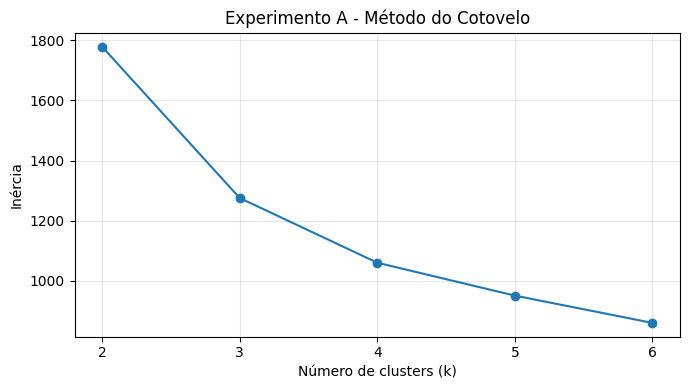

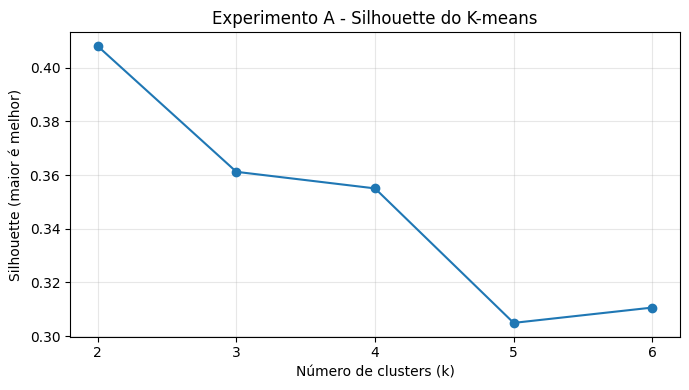

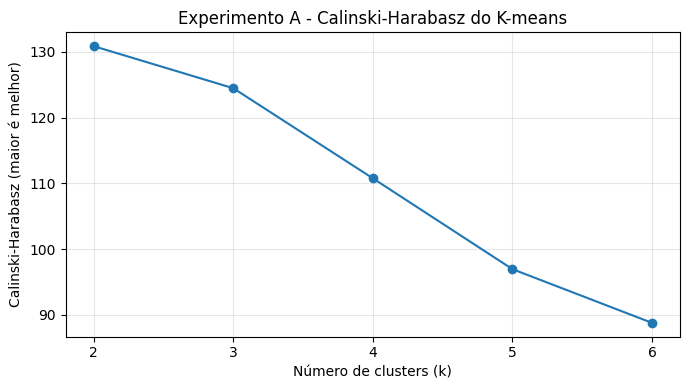

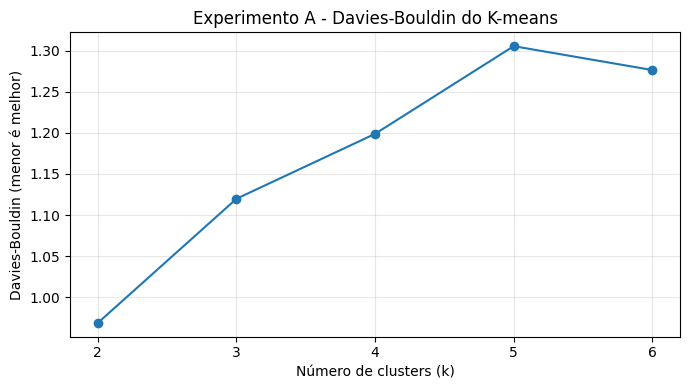

In [9]:
resultados_kmeans_a = avaliar_kmeans(base_a_padronizada)
display(resultados_kmeans_a.round(3))
grafico_metrica(resultados_kmeans_a, "inercia",
                "Experimento A - Método do Cotovelo", "Inércia")
grafico_metrica(resultados_kmeans_a, "silhouette",
                "Experimento A - Silhouette do K-means", "Silhouette (maior é melhor)")
grafico_metrica(resultados_kmeans_a, "calinski_harabasz",
                "Experimento A - Calinski-Harabasz do K-means",
                "Calinski-Harabasz (maior é melhor)")
grafico_metrica(resultados_kmeans_a, "davies_bouldin",
                "Experimento A - Davies-Bouldin do K-means",
                "Davies-Bouldin (menor é melhor)")

### A3. Escolha de k para K-means

Na base atual, k=2 tem Silhouette 0,408, Calinski-Harabasz 130,9 e Davies-Bouldin 0,969: os melhores valores dos três índices entre k=2 e k=6. A inércia cai de 1778,8 (k=2) para 1275,4 (k=3), mas segue caindo com k e não determina sozinha a escolha. Por isso adotamos k=2 para o resultado principal. A escolha descreve perfis macroeconômicos, não precisa coincidir com as três faixas do Regime_Inflacao.

Cluster_KMeans
0    121
1     53
Name: Meses, dtype: int64

Menor cluster: 53 meses


c:\Users\MARCUS VINICIUS\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but PCA was fitted with feature names
  warnings.warn(


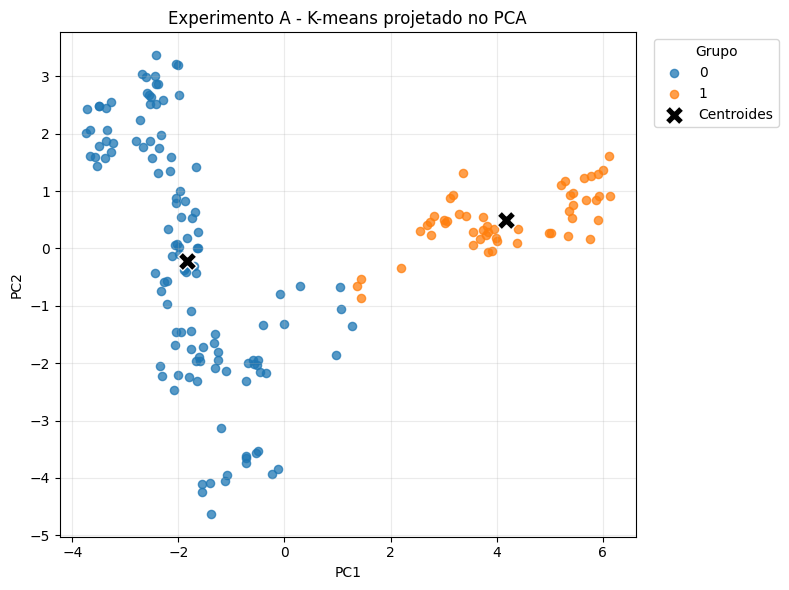

In [10]:
k_escolhido_a = 2
kmeans_a = KMeans(n_clusters=k_escolhido_a, random_state=42, n_init=50)
clusters_kmeans_a = kmeans_a.fit_predict(base_a_padronizada)
resultados_atrib_a = base_a.copy()
resultados_atrib_a["Cluster_KMeans"] = clusters_kmeans_a
display(resultados_atrib_a["Cluster_KMeans"].value_counts().sort_index().rename("Meses"))
print("Menor cluster:", resultados_atrib_a["Cluster_KMeans"].value_counts().min(), "meses")

# Os centroides estão no espaço padronizado, o mesmo em que pca_a foi ajustado.
centroides_pca_a = pca_a.transform(kmeans_a.cluster_centers_)
projecao_a_clusters = projecao_a.copy()
projecao_a_clusters["Cluster_KMeans"] = clusters_kmeans_a
grafico_pca_grupos(projecao_a, clusters_kmeans_a,
                   "Experimento A - K-means projetado no PCA",
                   centroides=centroides_pca_a)

### A4. Hierárquico Ward nos mesmos 174 meses

O dendrograma usa distância euclidiana e Ward sobre base_a_padronizada. Cada folha representa um mês; os rótulos das folhas foram ocultados para manter o gráfico legível.

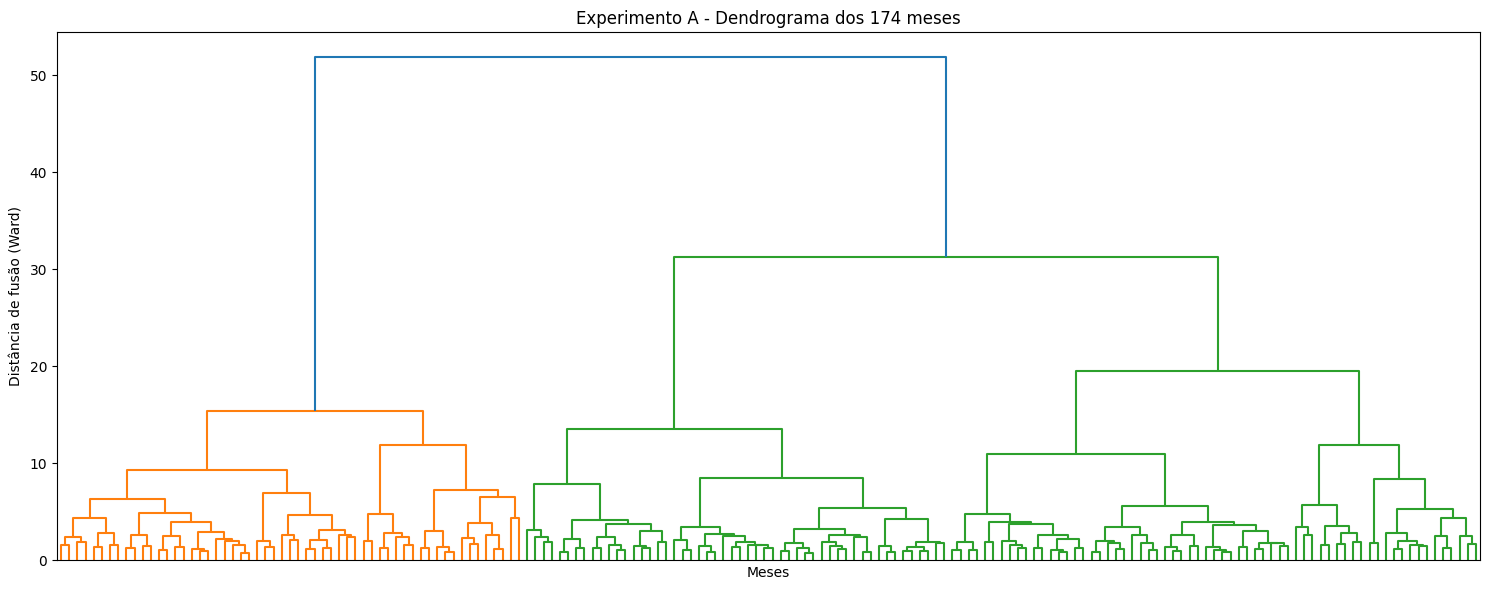

,k,silhouette,calinski_harabasz,davies_bouldin
0,2,0.400,129.323,1.008
1,3,0.361,120.675,1.121
2,4,0.353,103.384,1.151
3,5,0.300,91.438,1.387
4,6,0.280,83.621,1.409


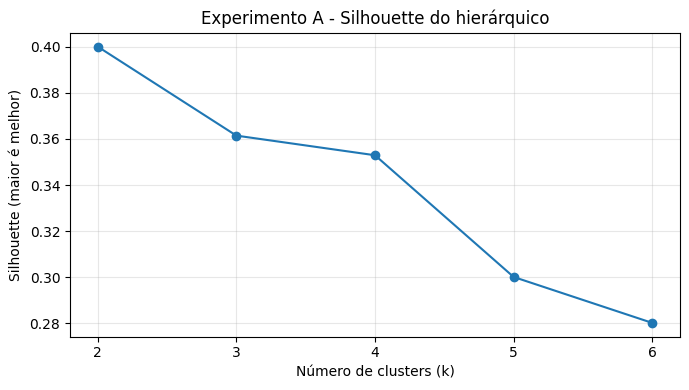

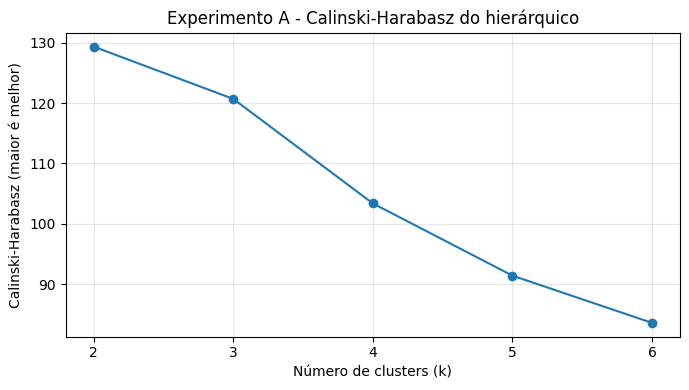

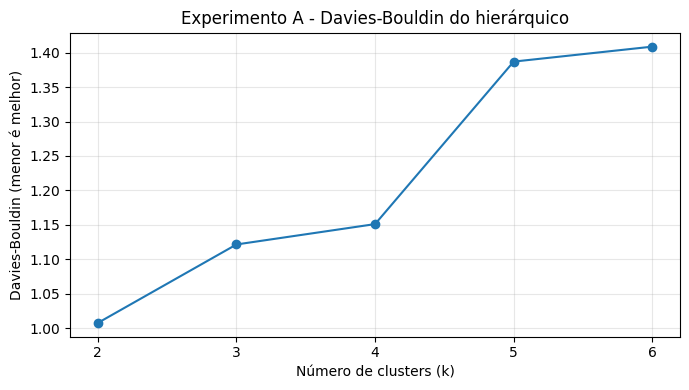

In [11]:
matriz_linkage_a = linkage(base_a_padronizada, method="ward", metric="euclidean")
fig, ax = plt.subplots(figsize=(15, 6))
dendrogram(matriz_linkage_a, no_labels=True, ax=ax)
ax.set(xlabel="Meses", ylabel="Distância de fusão (Ward)",
       title="Experimento A - Dendrograma dos 174 meses")
plt.tight_layout()
plt.show()

resultados_hierarquico_a = avaliar_hierarquico(base_a_padronizada)
display(resultados_hierarquico_a.round(3))
grafico_metrica(resultados_hierarquico_a, "silhouette",
                "Experimento A - Silhouette do hierárquico", "Silhouette (maior é melhor)")
grafico_metrica(resultados_hierarquico_a, "calinski_harabasz",
                "Experimento A - Calinski-Harabasz do hierárquico",
                "Calinski-Harabasz (maior é melhor)")
grafico_metrica(resultados_hierarquico_a, "davies_bouldin",
                "Experimento A - Davies-Bouldin do hierárquico",
                "Davies-Bouldin (menor é melhor)")

### A5. Escolha de k para o hierárquico

Na base atual, k=2 também apresenta o melhor Silhouette (0,400), o maior Calinski-Harabasz (129,3) e o menor Davies-Bouldin (1,008) entre as opções testadas. A última fusão do dendrograma ocorre a distância 51,85, acima da fusão anterior (31,27), compatível com um corte em dois grupos. Adotamos k=2 sem consultar Regime_Inflacao.

Cluster_Hierarquico
0    117
1     57
Name: Meses, dtype: int64

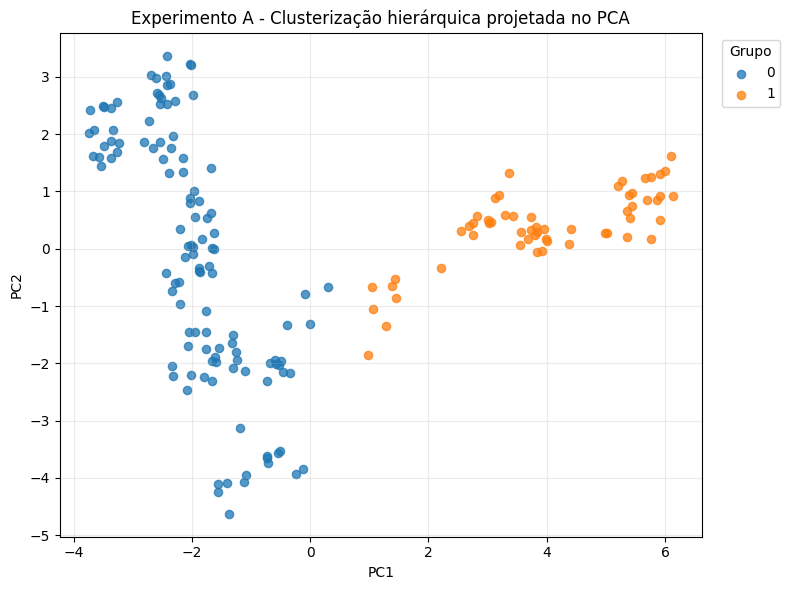

In [12]:
k_hierarquico_a = 2
hierarquico_a = AgglomerativeClustering(n_clusters=k_hierarquico_a, linkage="ward")
clusters_hierarquico_a = hierarquico_a.fit_predict(base_a_padronizada)
resultados_atrib_a["Cluster_Hierarquico"] = clusters_hierarquico_a
display(resultados_atrib_a["Cluster_Hierarquico"].value_counts().sort_index().rename("Meses"))
projecao_a_hierarquico = projecao_a.copy()
projecao_a_hierarquico["Cluster_Hierarquico"] = clusters_hierarquico_a
grafico_pca_grupos(projecao_a, clusters_hierarquico_a,
                   "Experimento A - Clusterização hierárquica projetada no PCA")

### A6. Comparação entre algoritmos e rótulo externo

O ARI entre K-means e Ward mede a concordância entre as duas partições, independentemente do nome numérico dos clusters. Só depois recuperamos Regime_Inflacao, uma classificação externa de referência criada a partir do IPCA. Ela não é uma verdade absoluta sobre os perfis econômicos.

,Modelo,K,Silhouette,Calinski_Harabasz,Davies_Bouldin
0,K-means,2,0.408,130.854,0.969
1,Hierárquico Ward,2,0.400,129.323,1.008


ARI K-means × hierárquico: 0.908
Regime × K-means: contagens e percentuais por cluster


Cluster,0,1
Regime_Inflacao,,
Alta / Acima da Meta,54,16
Deflação,16,11
Meta / Estável,51,26


Cluster,0,1
Regime_Inflacao,,
Alta / Acima da Meta,44.6,30.2
Deflação,13.2,20.8
Meta / Estável,42.1,49.1


Regime × hierárquico: contagens e percentuais por cluster


Cluster,0,1
Regime_Inflacao,,
Alta / Acima da Meta,50,20
Deflação,16,11
Meta / Estável,51,26


Cluster,0,1
Regime_Inflacao,,
Alta / Acima da Meta,42.7,35.1
Deflação,13.7,19.3
Meta / Estável,43.6,45.6


,Modelo,ARI_Regime,NMI_Regime
0,K-means,0.015,0.013
1,Hierárquico Ward,0.005,0.005


ARI perto de 1 indica forte concordância; perto de 0, concordância semelhante ao acaso.
NMI maior indica mais informação compartilhada entre as partições.


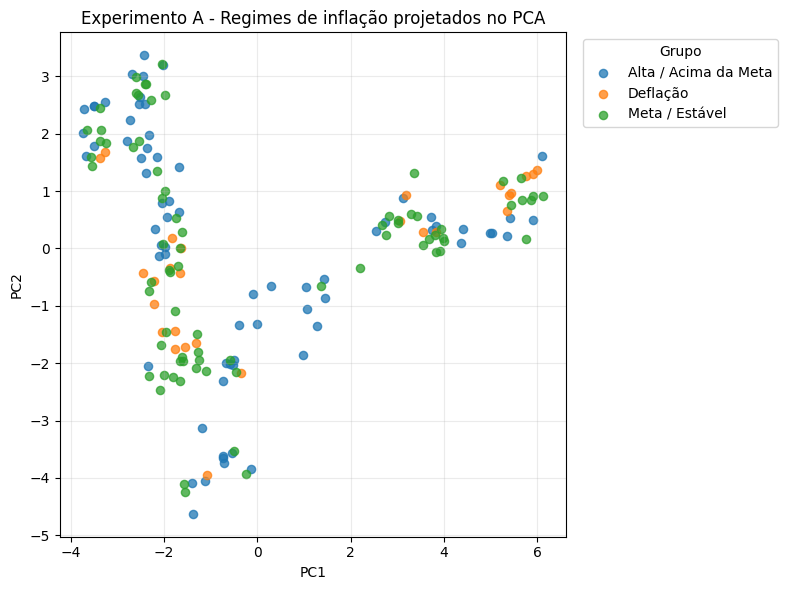

In [13]:
referencia_a = df.set_index("Date").loc[base_a.index, ["IPCA", "Regime_Inflacao"]].copy()
comparacao_interna_a = resumo_modelos(
    resultados_kmeans_a, resultados_hierarquico_a,
    k_escolhido_a, k_hierarquico_a,
    clusters_kmeans_a, clusters_hierarquico_a,
    referencia_a["Regime_Inflacao"],
)[["Modelo", "K", "Silhouette", "Calinski_Harabasz", "Davies_Bouldin"]]
display(comparacao_interna_a.round(3))
ARI_KMeans_vs_Hierarquico_a = adjusted_rand_score(
    clusters_kmeans_a, clusters_hierarquico_a
)
print(f"ARI K-means × hierárquico: {ARI_KMeans_vs_Hierarquico_a:.3f}")

print("Regime × K-means: contagens e percentuais por cluster")
contagem_regime_kmeans_a, percentual_regime_kmeans_a = tabelas_regime(
    referencia_a["Regime_Inflacao"], clusters_kmeans_a
)
print("Regime × hierárquico: contagens e percentuais por cluster")
contagem_regime_hierarquico_a, percentual_regime_hierarquico_a = tabelas_regime(
    referencia_a["Regime_Inflacao"], clusters_hierarquico_a
)
validacao_externa_a = resumo_modelos(
    resultados_kmeans_a, resultados_hierarquico_a,
    k_escolhido_a, k_hierarquico_a,
    clusters_kmeans_a, clusters_hierarquico_a,
    referencia_a["Regime_Inflacao"],
)[["Modelo", "ARI_Regime", "NMI_Regime"]]
display(validacao_externa_a.round(3))
print("ARI perto de 1 indica forte concordância; perto de 0, concordância semelhante ao acaso.")
print("NMI maior indica mais informação compartilhada entre as partições.")

projecao_a_regime = projecao_a.copy()
projecao_a_regime["Regime_Inflacao"] = referencia_a["Regime_Inflacao"]
grafico_pca_grupos(projecao_a, referencia_a["Regime_Inflacao"],
                   "Experimento A - Regimes de inflação projetados no PCA")

### A7. Perfis, IPCA e distribuição temporal

As médias e medianas abaixo usam os valores originais. O heatmap usa médias padronizadas para mostrar o que está acima ou abaixo da média da amostra. Associação entre indicadores e grupos não demonstra causalidade.

Experimento A - K-means: médias das variáveis originais


,USDBRL,Reservas Internacionais,Desemprego,SELIC,SalMinimo,PIB Mensal,QteOvos,INPC,IGP_DI,IPC_BR,Produção_Derivados_Petróleo,Consumo_Gasolina,Consumo_Óleo_Combustível,Consumo_Energia_Comercial,Consumo_Energia_Residencial,Estoque_Empregos_Formais_Total,Estoque_Empregos_Formais_Agropecuária,Estoque_Empregos_Formais_Construção
Cluster,,,,,,,,,,,,,,,,,,
0,3.55,368400.65,10.62,0.67,885.11,556849.16,277499.14,0.51,0.75,0.5,2625.80,518.47,61.99,7289.52,11349.79,38494736.10,1527977.64,2487847.12
1,5.28,349514.96,7.10,1.03,1411.40,985103.47,382914.23,0.33,0.07,0.3,3624.45,575.11,26.34,8410.75,14303.89,45283071.28,1808933.06,2877526.09


Experimento A - K-means: medianas das variáveis originais


,USDBRL,Reservas Internacionais,Desemprego,SELIC,SalMinimo,PIB Mensal,QteOvos,INPC,IGP_DI,IPC_BR,Produção_Derivados_Petróleo,Consumo_Gasolina,Consumo_Óleo_Combustível,Consumo_Energia_Comercial,Consumo_Energia_Residencial,Estoque_Empregos_Formais_Total,Estoque_Empregos_Formais_Agropecuária,Estoque_Empregos_Formais_Construção
Cluster,,,,,,,,,,,,,,,,,,
0,3.32,368752.0,11.7,0.64,937.0,543345.1,269936.0,0.47,0.59,0.49,2672.0,526.0,59.0,7309.0,11175.0,38255266.0,1525939.0,2367269.0
1,5.22,346415.0,7.0,1.03,1412.0,976537.3,386183.0,0.37,0.10,0.34,3541.0,573.0,30.0,8420.0,14386.0,45472529.0,1818124.0,2903762.0


Experimento A - K-means: médias padronizadas


,USDBRL,Reservas Internacionais,Desemprego,SELIC,SalMinimo,PIB Mensal,QteOvos,INPC,IGP_DI,IPC_BR,Produção_Derivados_Petróleo,Consumo_Gasolina,Consumo_Óleo_Combustível,Consumo_Energia_Comercial,Consumo_Energia_Residencial,Estoque_Empregos_Formais_Total,Estoque_Empregos_Formais_Agropecuária,Estoque_Empregos_Formais_Construção
Cluster,,,,,,,,,,,,,,,,,,
0,-0.42,0.40,0.38,-0.36,-0.56,-0.59,-0.52,0.13,0.22,0.15,-0.52,-0.32,0.39,-0.43,-0.52,-0.60,-0.60,-0.29
1,0.96,-0.92,-0.86,0.82,1.28,1.34,1.18,-0.31,-0.49,-0.35,1.19,0.73,-0.89,0.99,1.19,1.37,1.36,0.66


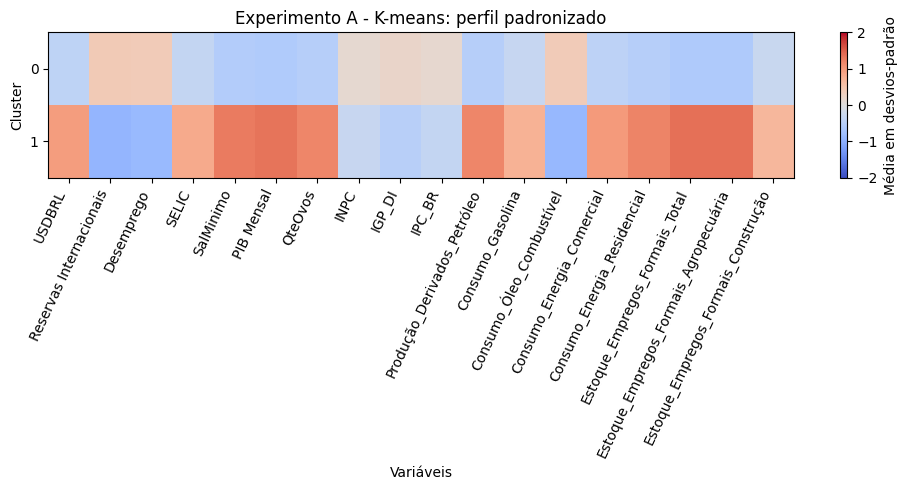

Experimento A - Ward: médias das variáveis originais


,USDBRL,Reservas Internacionais,Desemprego,SELIC,SalMinimo,PIB Mensal,QteOvos,INPC,IGP_DI,IPC_BR,Produção_Derivados_Petróleo,Consumo_Gasolina,Consumo_Óleo_Combustível,Consumo_Energia_Comercial,Consumo_Energia_Residencial,Estoque_Empregos_Formais_Total,Estoque_Empregos_Formais_Agropecuária,Estoque_Empregos_Formais_Construção
Cluster,,,,,,,,,,,,,,,,,,
0,3.49,368760.41,10.60,0.67,874.89,549259.17,275622.70,0.50,0.72,0.49,2611.68,518.06,62.95,7262.58,11284.79,38408567.28,1522683.37,2488885.23
1,5.27,350101.82,7.38,1.01,1395.44,970630.00,379368.32,0.38,0.19,0.33,3583.37,571.98,26.88,8387.37,14230.00,44983569.72,1800084.09,2848049.35


Experimento A - Ward: medianas das variáveis originais


,USDBRL,Reservas Internacionais,Desemprego,SELIC,SalMinimo,PIB Mensal,QteOvos,INPC,IGP_DI,IPC_BR,Produção_Derivados_Petróleo,Consumo_Gasolina,Consumo_Óleo_Combustível,Consumo_Energia_Comercial,Consumo_Energia_Residencial,Estoque_Empregos_Formais_Total,Estoque_Empregos_Formais_Agropecuária,Estoque_Empregos_Formais_Construção
Cluster,,,,,,,,,,,,,,,,,,
0,3.31,368981.0,11.7,0.61,937.0,538777.8,268896.0,0.44,0.58,0.49,2659.0,526.0,59.0,7287.0,11141.0,38160151.0,1524368.0,2337450.0
1,5.22,350767.0,7.4,1.02,1412.0,965547.0,381703.0,0.39,0.12,0.35,3516.0,572.0,30.0,8354.0,14366.0,45126112.0,1811895.0,2865032.0


Experimento A - Ward: médias padronizadas


,USDBRL,Reservas Internacionais,Desemprego,SELIC,SalMinimo,PIB Mensal,QteOvos,INPC,IGP_DI,IPC_BR,Produção_Derivados_Petróleo,Consumo_Gasolina,Consumo_Óleo_Combustível,Consumo_Energia_Comercial,Consumo_Energia_Residencial,Estoque_Empregos_Formais_Total,Estoque_Empregos_Formais_Agropecuária,Estoque_Empregos_Formais_Construção
Cluster,,,,,,,,,,,,,,,,,,
0,-0.46,0.43,0.37,-0.37,-0.60,-0.62,-0.55,0.09,0.18,0.14,-0.54,-0.33,0.42,-0.47,-0.56,-0.63,-0.63,-0.29
1,0.95,-0.88,-0.76,0.77,1.22,1.28,1.12,-0.19,-0.37,-0.28,1.12,0.68,-0.87,0.96,1.15,1.28,1.30,0.59


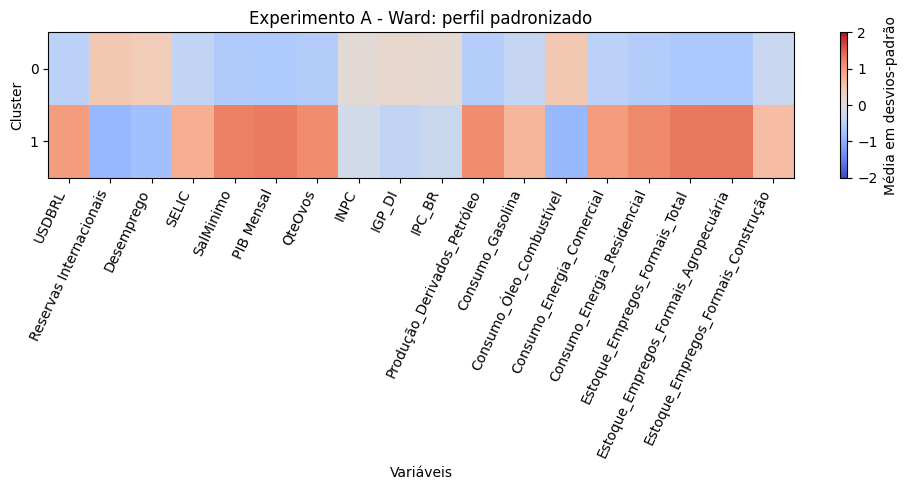

IPCA geral por cluster K-means; usado apenas para interpretação:


,mean,median,min,max
0,0.479,0.47,-0.61,1.95
1,0.325,0.26,-0.74,1.42


IPCA geral por cluster hierárquico:


,mean,median,min,max
0,0.452,0.45,-0.61,1.95
1,0.392,0.38,-0.74,1.58


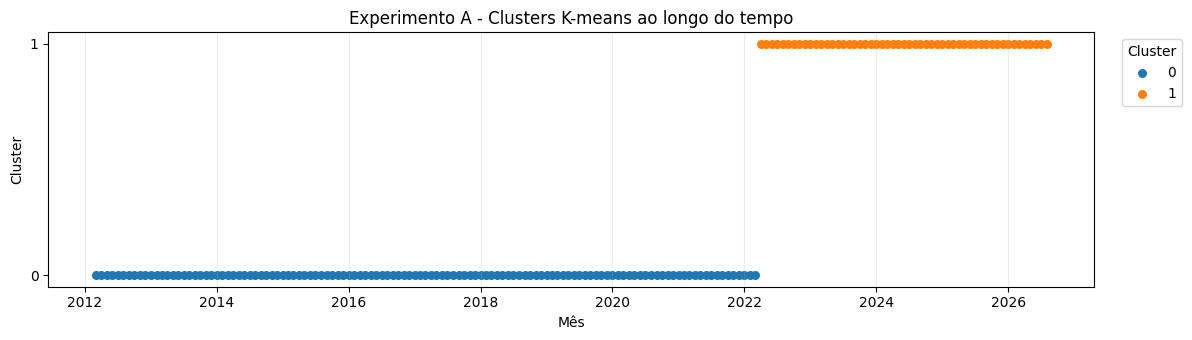

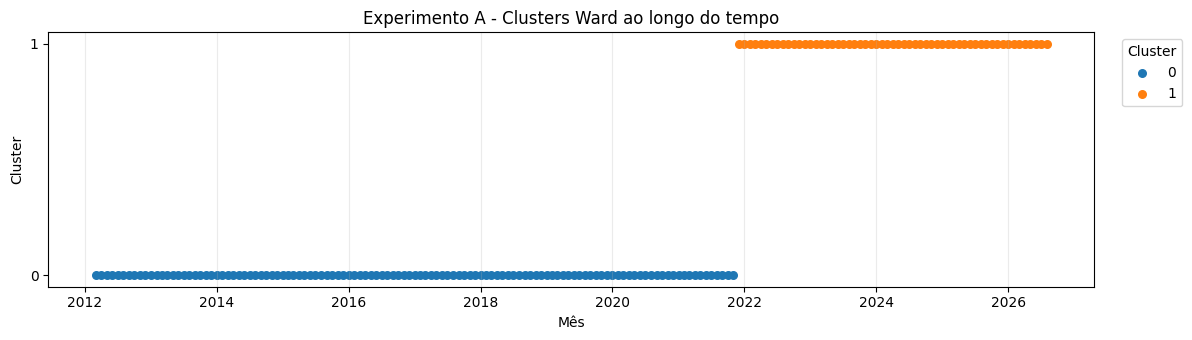

In [14]:
medias_kmeans_a, medianas_kmeans_a, perfil_padronizado_kmeans_a = perfis_cluster(
    base_a, base_a_padronizada, clusters_kmeans_a, "Experimento A - K-means"
)
medias_hierarquico_a, medianas_hierarquico_a, perfil_padronizado_hierarquico_a = perfis_cluster(
    base_a, base_a_padronizada, clusters_hierarquico_a, "Experimento A - Ward"
)
print("IPCA geral por cluster K-means; usado apenas para interpretação:")
ipca_por_kmeans_a = referencia_a["IPCA"].groupby(clusters_kmeans_a).agg(
    ["mean", "median", "min", "max"]
)
display(ipca_por_kmeans_a.round(3))
print("IPCA geral por cluster hierárquico:")
ipca_por_hierarquico_a = referencia_a["IPCA"].groupby(clusters_hierarquico_a).agg(
    ["mean", "median", "min", "max"]
)
display(ipca_por_hierarquico_a.round(3))

grafico_temporal(base_a.index, clusters_kmeans_a,
                "Experimento A - Clusters K-means ao longo do tempo")
grafico_temporal(base_a.index, clusters_hierarquico_a,
                "Experimento A - Clusters Ward ao longo do tempo")

Como a base é temporal, meses consecutivos apresentam dependência e os clusters podem refletir períodos históricos. A tabela seguinte mostra exemplos de meses cujo Regime_Inflacao difere do regime mais frequente em seu cluster; são casos para discussão, sem explicação causal presumida.

In [15]:
print("Casos divergentes do K-means:")
casos_divergentes_kmeans_a = casos_divergentes(
    base_a, referencia_a, clusters_kmeans_a
)
print("Casos divergentes do hierárquico:")
casos_divergentes_hierarquico_a = casos_divergentes(
    base_a, referencia_a, clusters_hierarquico_a
)
tabela_final_a = resumo_modelos(
    resultados_kmeans_a, resultados_hierarquico_a,
    k_escolhido_a, k_hierarquico_a,
    clusters_kmeans_a, clusters_hierarquico_a,
    referencia_a["Regime_Inflacao"],
)
display(tabela_final_a.round(3))
print(f"ARI_KMeans_vs_Hierarquico = {ARI_KMeans_vs_Hierarquico_a:.3f}")

Casos divergentes do K-means:


,Regime_Inflacao,IPCA,Cluster,Regime_predominante_no_cluster,USDBRL,IGP_DI,SELIC,Desemprego
Date,,,,,,,,
2012-03-01,Deflação,-0.08,0,Alta / Acima da Meta,1.82,0.56,0.82,8.0
2012-05-01,Meta / Estável,0.48,0,Alta / Acima da Meta,2.02,0.91,0.74,7.7
2012-06-01,Deflação,-0.31,0,Alta / Acima da Meta,2.02,0.69,0.64,7.6
2012-07-01,Meta / Estável,0.06,0,Alta / Acima da Meta,2.05,1.52,0.68,7.5
2012-08-01,Meta / Estável,0.44,0,Alta / Acima da Meta,2.04,1.29,0.69,7.3
2016-09-01,Deflação,-0.04,0,Alta / Acima da Meta,3.25,0.03,1.11,11.9
2022-04-01,Alta / Acima da Meta,1.42,1,Meta / Estável,4.92,0.41,0.83,10.5
2022-05-01,Alta / Acima da Meta,1.03,1,Meta / Estável,4.73,0.69,1.03,9.8
2022-08-01,Alta / Acima da Meta,0.73,1,Meta / Estável,5.18,-0.55,1.17,8.9


Casos divergentes do hierárquico:


,Regime_Inflacao,IPCA,Cluster,Regime_predominante_no_cluster,USDBRL,IGP_DI,SELIC,Desemprego
Date,,,,,,,,
2012-03-01,Deflação,-0.08,0,Meta / Estável,1.82,0.56,0.82,8.0
2012-04-01,Alta / Acima da Meta,0.55,0,Meta / Estável,1.89,1.02,0.71,7.8
2012-06-01,Deflação,-0.31,0,Meta / Estável,2.02,0.69,0.64,7.6
2012-09-01,Alta / Acima da Meta,0.92,0,Meta / Estável,2.03,0.88,0.54,7.1
2012-10-01,Alta / Acima da Meta,1.00,0,Meta / Estável,2.03,-0.31,0.61,6.9
2016-09-01,Deflação,-0.04,0,Meta / Estável,3.25,0.03,1.11,11.9


,Modelo,K,Silhouette,Calinski_Harabasz,Davies_Bouldin,ARI_Regime,NMI_Regime
0,K-means,2,0.408,130.854,0.969,0.015,0.013
1,Hierárquico Ward,2,0.400,129.323,1.008,0.005,0.005


ARI_KMeans_vs_Hierarquico = 0.908


### Leitura dos resultados do experimento A

Os dois metodos chegam a particoes muito parecidas (ARI entre algoritmos de aproximadamente 0,908), mas sua concordancia com Regime_Inflacao e baixa: ARI de 0,015 para K-means e 0,005 para Ward. No K-means, o cluster 0 concentra todos os meses de 2012 a 2021 e tres meses de 2022; o cluster 1 inclui nove meses de 2022 e todos os meses de 2023 a agosto de 2026. A separacao, portanto, acompanha fortemente o periodo historico. No perfil padronizado do cluster 1, USDBRL (+0,96), PIB Mensal (+1,34) e Estoque_Empregos_Formais_Total (+1,37) estao acima da media da amostra; Desemprego (-0,86) esta abaixo. Esses valores descrevem os dados observados, sem atribuir causalidade. O IPCA medio foi 0,479 no cluster 0 e 0,325 no cluster 1. Para investigar regimes de inflacao, seria util testar futuramente transformacoes que reduzam a influencia da tendencia temporal.

## Experimento B componentes do IPCA

Base apenas com os componentes setoriais do IPCA. Um filtro de correlacao retira colunas muito semelhantes (|r| >= 0,85). Se nenhuma atingir esse limiar, todas permanecem.


In [16]:
limiar_correlacao = 0.85
componentes_reduzidos = []
componentes_removidos = []

for coluna in componentes_ipca:
    redundante = any(
        abs(df[coluna].corr(df[mantida])) >= limiar_correlacao
        for mantida in componentes_reduzidos
    )
    if redundante:
        componentes_removidos.append(coluna)
    else:
        componentes_reduzidos.append(coluna)

base_b = df.set_index('Date')[componentes_reduzidos].copy()
print(f'Experimento B: {base_b.shape[0]} meses e {base_b.shape[1]} componentes do IPCA')
print('Componentes mantidos:', componentes_reduzidos)
print('Componentes removidos por redundancia:', componentes_removidos)


Experimento B: 174 meses e 6 componentes do IPCA
Componentes mantidos: ['IPCA_Transportes', 'IPCA Alimentação_bebidas', 'IPCA_Saúde_cuidados_pessoais', 'IPCA_Vestuário', 'IPCA_Educação', 'IPCA_Despesas_Pessoais']
Componentes removidos por redundancia: []


### Correlacao entre os componentes de B

A matriz abaixo documenta a verificacao de redundancia. O maior valor absoluto fora da diagonal e aproximadamente 0,287; por isso o filtro de 0,85 preservou todos os seis componentes.

In [17]:
correlacao_componentes_b = df[componentes_ipca].corr()
display(correlacao_componentes_b.round(3))
mascara_fora_diagonal = np.triu(np.ones(correlacao_componentes_b.shape, dtype=bool), k=1)
maior_correlacao_b = correlacao_componentes_b.abs().where(mascara_fora_diagonal).max().max()
print(f'Maior correlacao absoluta entre componentes distintos: {maior_correlacao_b:.3f}')

,IPCA_Transportes,IPCA Alimentação_bebidas,IPCA_Saúde_cuidados_pessoais,IPCA_Vestuário,IPCA_Educação,IPCA_Despesas_Pessoais
IPCA_Transportes,1.000,0.195,-0.104,0.038,0.037,0.026
IPCA Alimentação_bebidas,0.195,1.000,0.122,0.157,0.003,0.212
IPCA_Saúde_cuidados_pessoais,-0.104,0.122,1.000,0.287,0.122,0.095
IPCA_Vestuário,0.038,0.157,0.287,1.000,-0.181,0.086
IPCA_Educação,0.037,0.003,0.122,-0.181,1.000,0.007
IPCA_Despesas_Pessoais,0.026,0.212,0.095,0.086,0.007,1.000


Maior correlacao absoluta entre componentes distintos: 0.287


### Análise completa do experimento B

Os seis componentes reais do IPCA passaram pelo filtro de correlação acima. Nenhum ultrapassou |r|=0,85, portanto nenhum foi removido. O IPCA geral e Regime_Inflacao não entram no treinamento. Como os componentes pertencem ao índice geral, a comparação posterior com as faixas do IPCA tende a ser mais direta que em A e deve ser lida como associação, não validação independente.

In [18]:
def executar_analise_completa(nome, base, referencia, k_kmeans, k_hierarquico):
    # Executa os modelos no espaço padronizado; o PCA serve apenas para gráficos.
    padronizada = pd.DataFrame(StandardScaler().fit_transform(base),
                               index=base.index, columns=base.columns)
    pca_2d = PCA(n_components=2).fit(padronizada)
    projecao = pd.DataFrame(pca_2d.transform(padronizada),
                            index=base.index, columns=["PC1", "PC2"])
    pca_todos = PCA().fit(padronizada)
    pca_tabela = pd.DataFrame({
        "Componente": np.arange(1, base.shape[1] + 1),
        "Variancia_Explicada": pca_todos.explained_variance_ratio_,
        "Variancia_Acumulada": np.cumsum(pca_todos.explained_variance_ratio_),
    })
    print(f"{nome}: {base.shape[0]} meses, {base.shape[1]} variáveis")
    print(f"PCA 2D: {pca_2d.explained_variance_ratio_.sum():.1%} da variância")
    display(pca_tabela.round(3))
    fig, ax = plt.subplots(figsize=(7, 4))
    ax.plot(pca_tabela["Componente"], pca_tabela["Variancia_Acumulada"], marker="o")
    ax.axhline(0.8, color="orange", linestyle="--", label="80%")
    ax.axhline(0.9, color="red", linestyle="--", label="90%")
    ax.set(xlabel="Componentes", ylabel="Variância acumulada",
           title=f"{nome} - PCA completo")
    ax.legend()
    ax.grid(alpha=0.25)
    plt.tight_layout()
    plt.show()

    km_resultados = avaliar_kmeans(padronizada)
    wd_resultados = avaliar_hierarquico(padronizada)
    print("K-means: métricas por k")
    display(km_resultados.round(3))
    print("Hierárquico Ward: métricas por k")
    display(wd_resultados.round(3))
    for coluna, titulo in [("inercia", "Método do Cotovelo"),
                           ("silhouette", "Silhouette"),
                           ("calinski_harabasz", "Calinski-Harabasz"),
                           ("davies_bouldin", "Davies-Bouldin")]:
        grafico_metrica(km_resultados, coluna, f"{nome} - K-means: {titulo}", titulo)
    for coluna, titulo in [("silhouette", "Silhouette"),
                           ("calinski_harabasz", "Calinski-Harabasz"),
                           ("davies_bouldin", "Davies-Bouldin")]:
        grafico_metrica(wd_resultados, coluna, f"{nome} - Ward: {titulo}", titulo)

    matriz_linkage = linkage(padronizada, method="ward", metric="euclidean")
    fig, ax = plt.subplots(figsize=(15, 5))
    dendrogram(matriz_linkage, no_labels=True, ax=ax)
    ax.set(xlabel="Meses", ylabel="Distância de fusão",
           title=f"{nome} - Dendrograma dos meses")
    plt.tight_layout()
    plt.show()

    modelo_km = KMeans(n_clusters=k_kmeans, random_state=42, n_init=50)
    grupos_km = modelo_km.fit_predict(padronizada)
    modelo_wd = AgglomerativeClustering(n_clusters=k_hierarquico, linkage="ward")
    grupos_wd = modelo_wd.fit_predict(padronizada)
    print("Tamanhos K-means:", pd.Series(grupos_km).value_counts().sort_index().to_dict())
    print("Tamanhos Ward:", pd.Series(grupos_wd).value_counts().sort_index().to_dict())
    centroides = pca_2d.transform(modelo_km.cluster_centers_)
    grafico_pca_grupos(projecao, grupos_km, f"{nome} - K-means no PCA", centroides)
    grafico_pca_grupos(projecao, grupos_wd, f"{nome} - Ward no PCA")
    grafico_pca_grupos(projecao, referencia["Regime_Inflacao"],
                       f"{nome} - Regime_Inflacao no PCA")

    print("Regime × K-means: contagens e percentuais por cluster")
    tabelas_regime(referencia["Regime_Inflacao"], grupos_km)
    print("Regime × Ward: contagens e percentuais por cluster")
    tabelas_regime(referencia["Regime_Inflacao"], grupos_wd)
    perfis_km = perfis_cluster(base, padronizada, grupos_km, f"{nome} - K-means")
    perfis_wd = perfis_cluster(base, padronizada, grupos_wd, f"{nome} - Ward")
    print("IPCA geral por cluster K-means:")
    display(referencia["IPCA"].groupby(grupos_km).agg(
        ["mean", "median", "min", "max"]).round(3))
    print("IPCA geral por cluster Ward:")
    display(referencia["IPCA"].groupby(grupos_wd).agg(
        ["mean", "median", "min", "max"]).round(3))
    grafico_temporal(base.index, grupos_km, f"{nome} - K-means ao longo do tempo")
    grafico_temporal(base.index, grupos_wd, f"{nome} - Ward ao longo do tempo")
    print("Casos divergentes K-means:")
    divergentes_km = casos_divergentes(base, referencia, grupos_km)
    print("Casos divergentes Ward:")
    divergentes_wd = casos_divergentes(base, referencia, grupos_wd)
    resumo = resumo_modelos(km_resultados, wd_resultados, k_kmeans,
                            k_hierarquico, grupos_km, grupos_wd,
                            referencia["Regime_Inflacao"])
    display(resumo.round(3))
    concordancia = adjusted_rand_score(grupos_km, grupos_wd)
    print(f"ARI K-means × Ward = {concordancia:.3f}")
    return {
        "base_padronizada": padronizada, "projecao": projecao, "pca": pca_2d,
        "resultado_pca": pca_tabela, "resultados_kmeans": km_resultados,
        "resultados_hierarquico": wd_resultados,
        "clusters_kmeans": grupos_km, "clusters_hierarquico": grupos_wd,
        "modelo_kmeans": modelo_km, "modelo_hierarquico": modelo_wd,
        "perfis_kmeans": perfis_km, "perfis_hierarquico": perfis_wd,
        "divergentes_kmeans": divergentes_km,
        "divergentes_hierarquico": divergentes_wd,
        "tabela_final": resumo, "ARI_KMeans_vs_Hierarquico": concordancia,
    }

### B. Escolha de k e execução

Nos seis componentes da base atual, o K-means em k=5 apresentou o maior Silhouette (0,249) e o menor Davies-Bouldin (1,283); Calinski-Harabasz foi maior em k=3 (40,9 contra 40,1 em k=5). Escolhemos k=5 para investigar os perfis adicionais. No Ward, k=4 obteve o maior Silhouette (0,235); k=5 teve Davies-Bouldin ligeiramente menor, mas produziu grupos menores. Adotamos k=4. Essas escolhas usam apenas métricas internas; Regime_Inflacao é consultado depois.

Experimento B: 174 meses, 6 variáveis
PCA 2D: 44.6% da variância


,Componente,Variancia_Explicada,Variancia_Acumulada
0,1,0.250,0.250
1,2,0.196,0.446
2,3,0.186,0.632
3,4,0.155,0.787
4,5,0.118,0.905
5,6,0.095,1.000


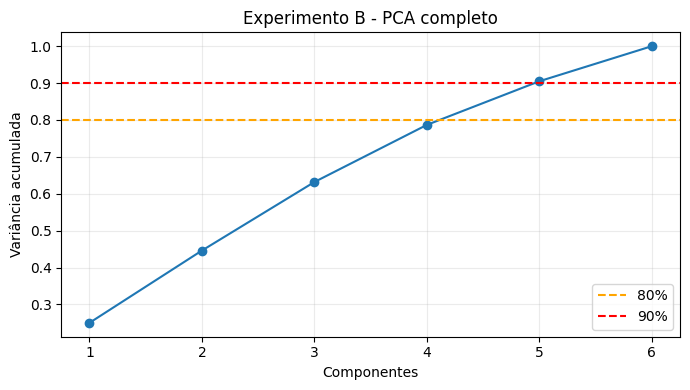

K-means: métricas por k


,k,inercia,silhouette,calinski_harabasz,davies_bouldin
0,2,862.886,0.187,36.102,1.961
1,3,706.388,0.225,40.864,1.515
2,4,606.886,0.238,40.815,1.399
3,5,535.628,0.249,40.100,1.283
4,6,492.388,0.205,37.641,1.362


Hierárquico Ward: métricas por k


,k,silhouette,calinski_harabasz,davies_bouldin
0,2,0.179,33.082,2.015
1,3,0.223,39.298,1.546
2,4,0.235,37.587,1.394
3,5,0.221,35.529,1.237
4,6,0.189,34.306,1.487


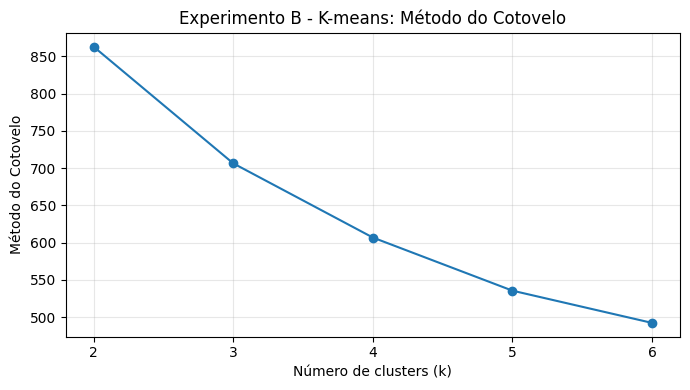

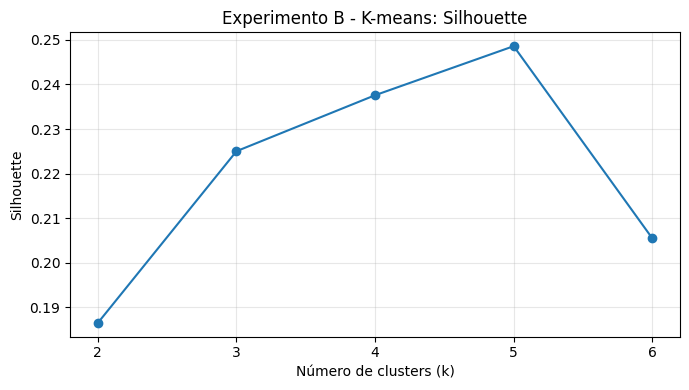

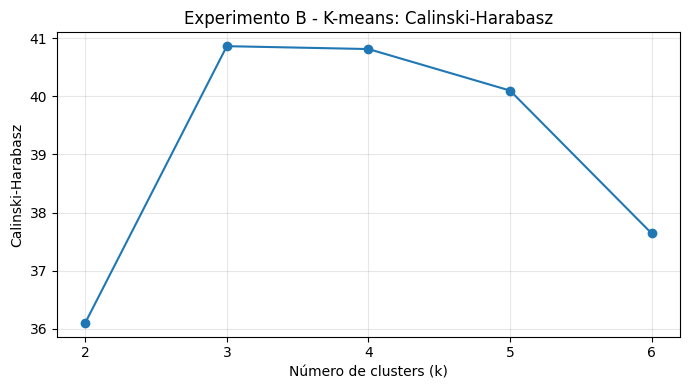

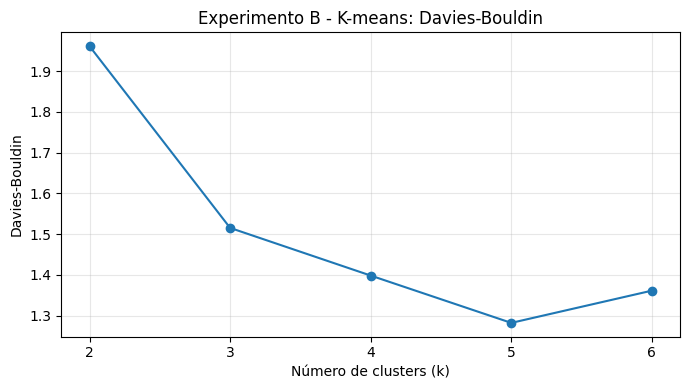

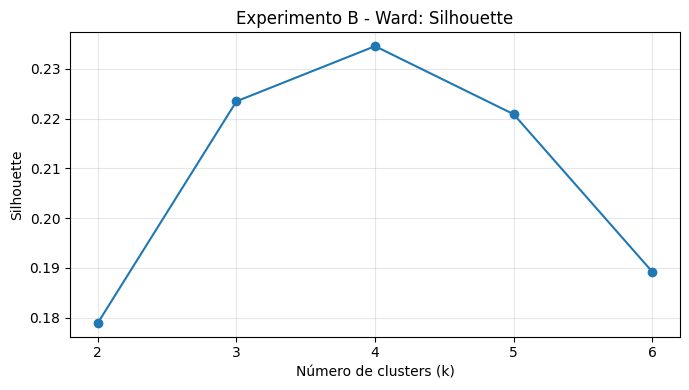

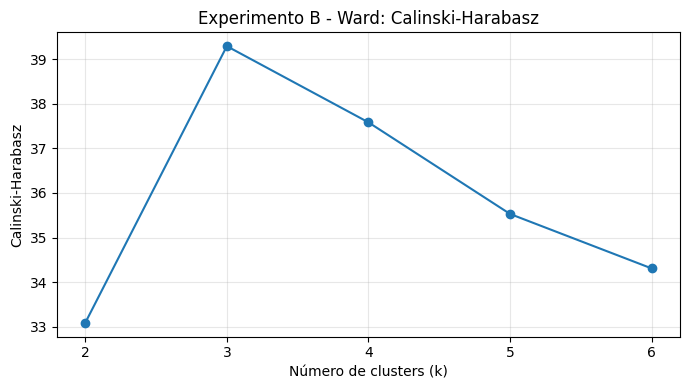

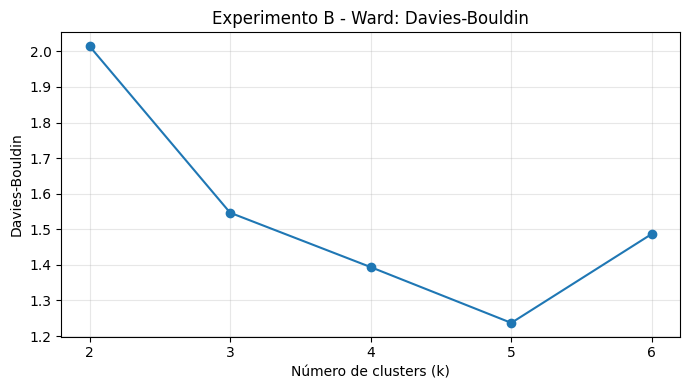

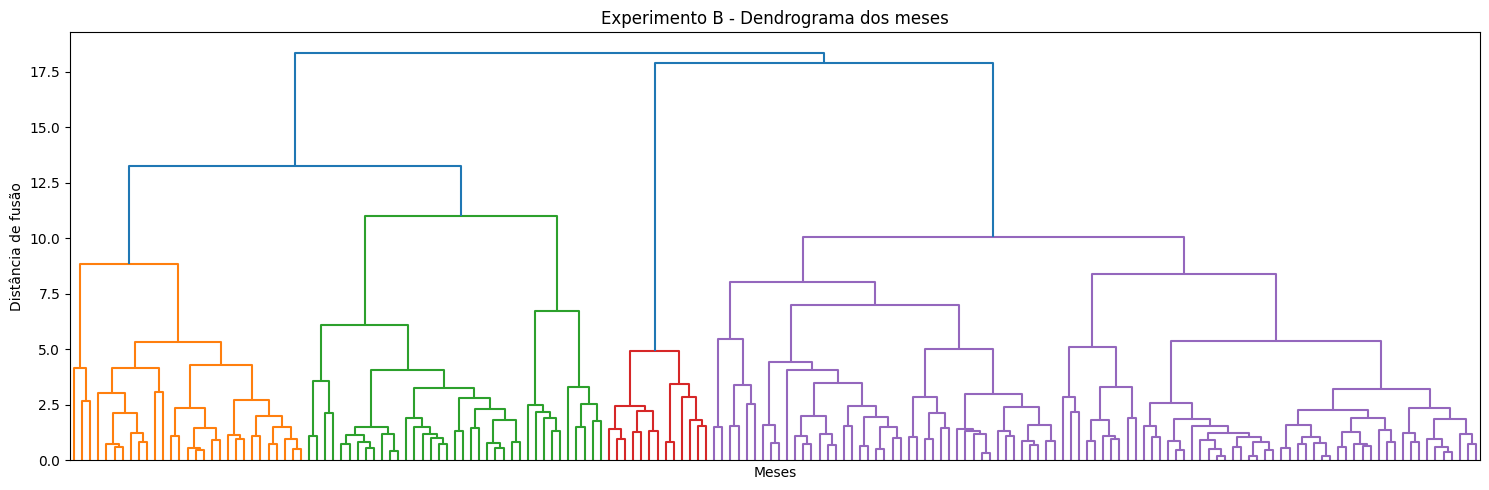

Tamanhos K-means: {0: 38, 1: 29, 2: 74, 3: 20, 4: 13}
Tamanhos Ward: {0: 37, 1: 95, 2: 13, 3: 29}


c:\Users\MARCUS VINICIUS\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but PCA was fitted with feature names
  warnings.warn(


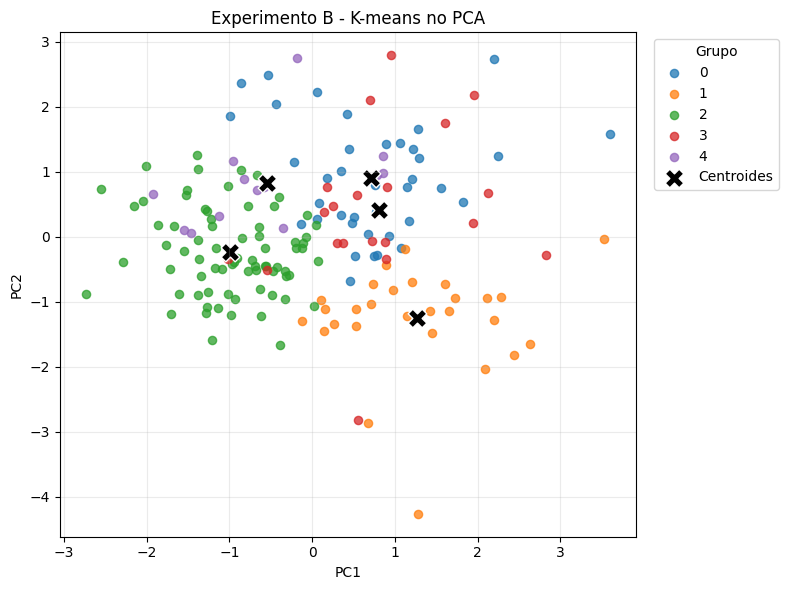

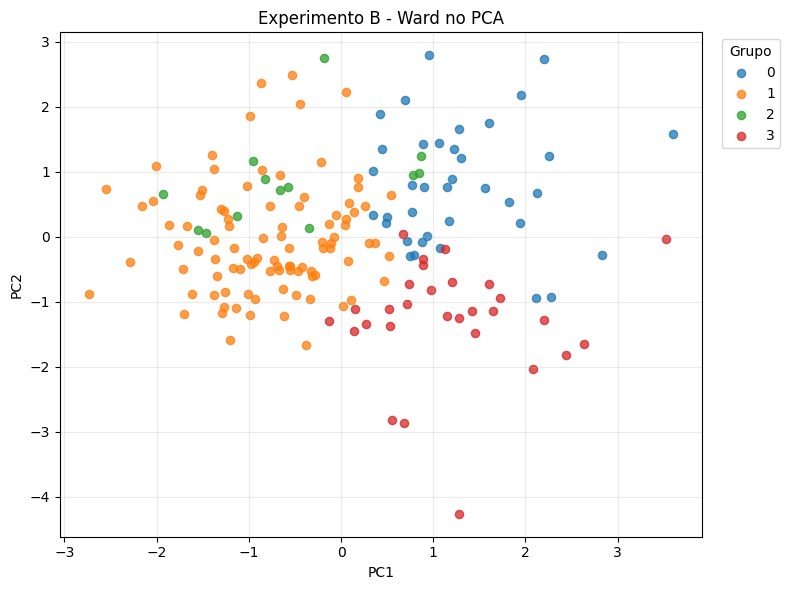

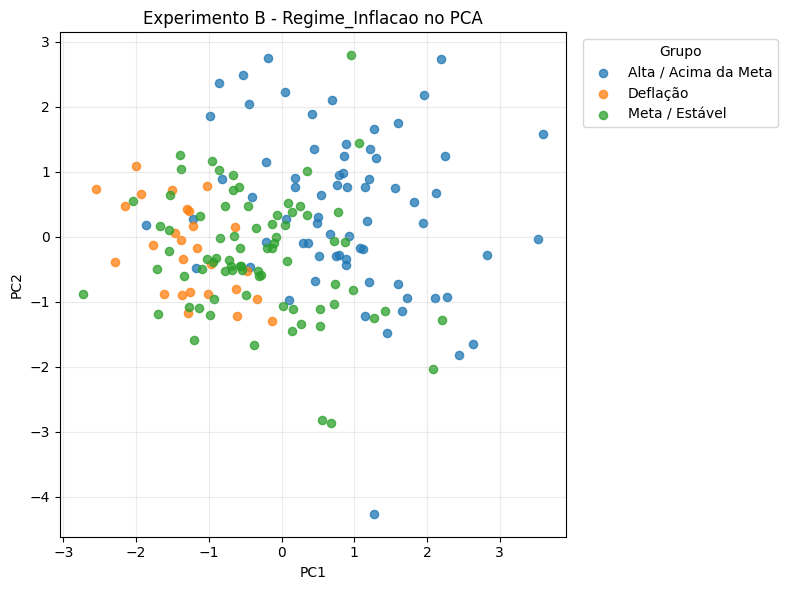

Regime × K-means: contagens e percentuais por cluster


Cluster,0,1,2,3,4
Regime_Inflacao,,,,,
Alta / Acima da Meta,32,15,6,12,5
Deflação,0,1,24,0,2
Meta / Estável,6,13,44,8,6


Cluster,0,1,2,3,4
Regime_Inflacao,,,,,
Alta / Acima da Meta,84.2,51.7,8.1,60.0,38.5
Deflação,0.0,3.4,32.4,0.0,15.4
Meta / Estável,15.8,44.8,59.5,40.0,46.2


Regime × Ward: contagens e percentuais por cluster


Cluster,0,1,2,3
Regime_Inflacao,,,,
Alta / Acima da Meta,30,21,5,14
Deflação,0,24,2,1
Meta / Estável,7,50,6,14


...

,IPCA_Transportes,IPCA Alimentação_bebidas,IPCA_Saúde_cuidados_pessoais,IPCA_Vestuário,IPCA_Educação,IPCA_Despesas_Pessoais
Cluster,,,,,,
0,1.32,1.20,0.34,0.72,0.19,0.48
1,-0.08,0.76,1.16,0.92,0.12,0.48
2,0.14,0.10,0.35,0.11,0.12,0.32
3,0.12,0.86,0.52,0.18,0.22,1.27
4,0.53,0.56,0.66,-0.11,5.08,0.42


Experimento B - K-means: medianas das variáveis originais


,IPCA_Transportes,IPCA Alimentação_bebidas,IPCA_Saúde_cuidados_pessoais,IPCA_Vestuário,IPCA_Educação,IPCA_Despesas_Pessoais
Cluster,,,,,,
0,1.35,1.14,0.40,0.74,0.10,0.52
1,0.00,0.72,1.16,0.79,0.08,0.51
2,0.20,0.04,0.40,0.20,0.08,0.35
3,0.33,0.88,0.48,0.15,0.12,1.21
4,0.61,0.70,0.65,-0.24,5.21,0.33


Experimento B - K-means: médias padronizadas


,IPCA_Transportes,IPCA Alimentação_bebidas,IPCA_Saúde_cuidados_pessoais,IPCA_Vestuário,IPCA_Educação,IPCA_Despesas_Pessoais
Cluster,,,,,,
0,0.92,0.85,-0.44,0.60,-0.24,-0.05
1,-0.46,0.25,1.51,0.93,-0.29,-0.04
2,-0.25,-0.64,-0.42,-0.44,-0.29,-0.46
3,-0.26,0.39,-0.03,-0.32,-0.22,1.99
4,0.14,-0.01,0.33,-0.81,3.32,-0.19


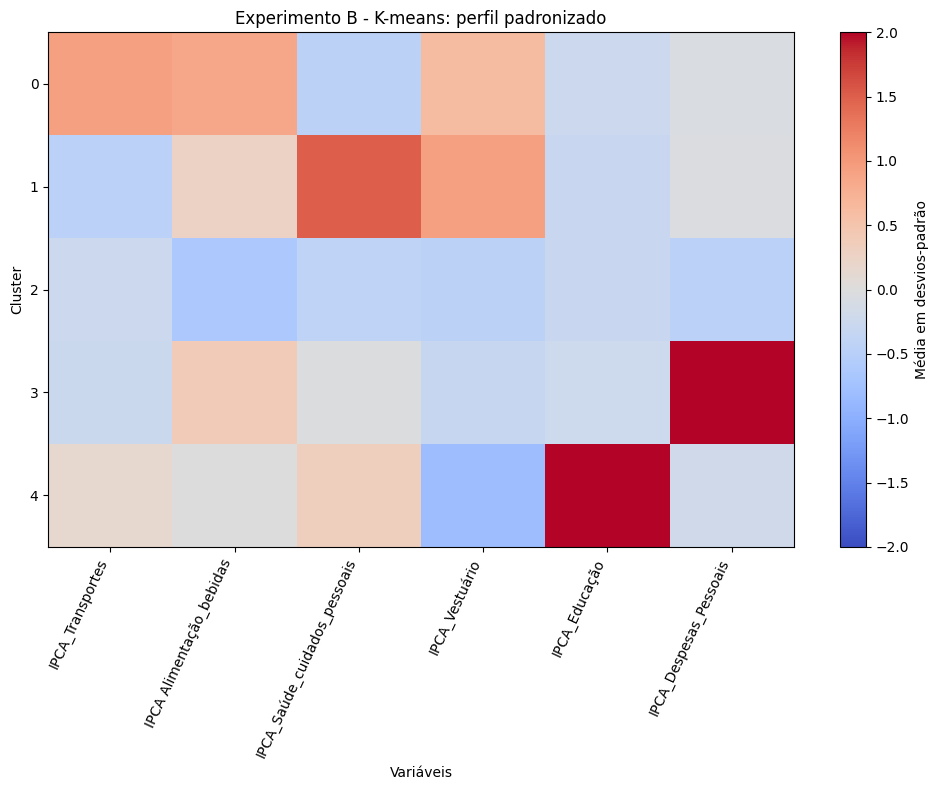

Experimento B - Ward: médias das variáveis originais


,IPCA_Transportes,IPCA Alimentação_bebidas,IPCA_Saúde_cuidados_pessoais,IPCA_Vestuário,IPCA_Educação,IPCA_Despesas_Pessoais
Cluster,,,,,,
0,1.07,1.29,0.48,0.72,0.16,0.84
1,0.31,0.22,0.34,0.16,0.15,0.37
2,0.53,0.56,0.66,-0.11,5.08,0.42
3,-0.29,0.82,1.14,0.81,0.16,0.51


Experimento B - Ward: medianas das variáveis originais


,IPCA_Transportes,IPCA Alimentação_bebidas,IPCA_Saúde_cuidados_pessoais,IPCA_Vestuário,IPCA_Educação,IPCA_Despesas_Pessoais
Cluster,,,,,,
0,1.19,1.17,0.42,0.80,0.10,0.65
1,0.30,0.17,0.40,0.23,0.08,0.36
2,0.61,0.70,0.65,-0.24,5.21,0.33
3,-0.06,0.78,1.16,0.65,0.09,0.51


Experimento B - Ward: médias padronizadas


,IPCA_Transportes,IPCA Alimentação_bebidas,IPCA_Saúde_cuidados_pessoais,IPCA_Vestuário,IPCA_Educação,IPCA_Despesas_Pessoais
Cluster,,,,,,
0,0.68,0.96,-0.10,0.60,-0.26,0.88
1,-0.08,-0.48,-0.45,-0.35,-0.27,-0.32
2,0.14,-0.01,0.33,-0.81,3.32,-0.19
3,-0.67,0.34,1.46,0.74,-0.27,0.03


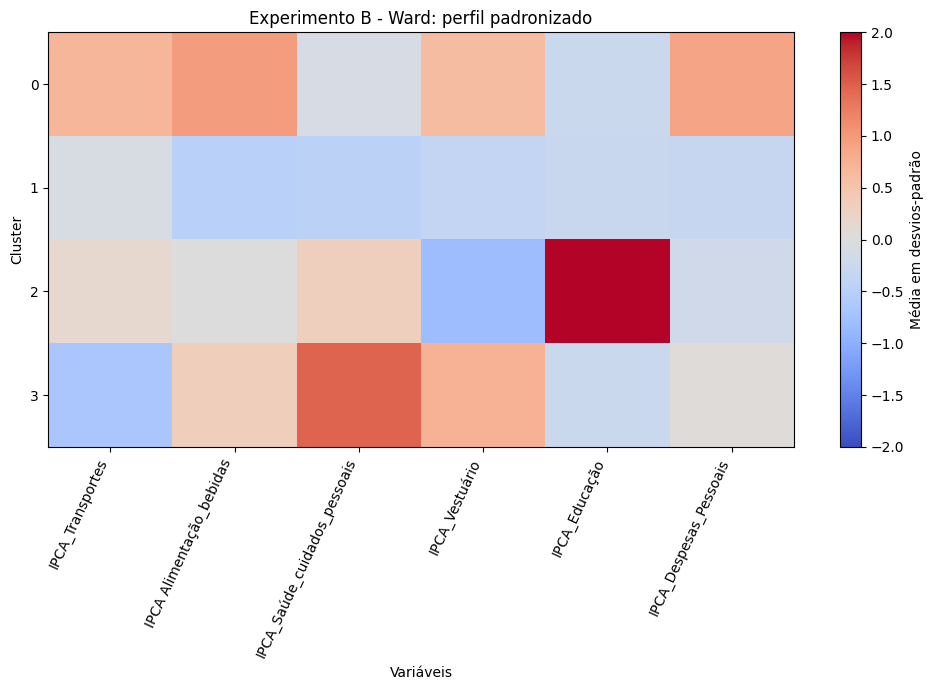

IPCA geral por cluster K-means:


,mean,median,min,max
0,0.910,0.855,0.06,1.95
1,0.571,0.560,-0.01,1.58
2,0.104,0.110,-0.74,0.71
3,0.586,0.605,0.06,1.06
4,0.358,0.380,-0.20,1.06


IPCA geral por cluster Ward:


,mean,median,min,max
0,0.932,0.92,0.30,1.95
1,0.223,0.14,-0.74,1.61
2,0.358,0.38,-0.20,1.06
3,0.513,0.49,-0.01,1.42


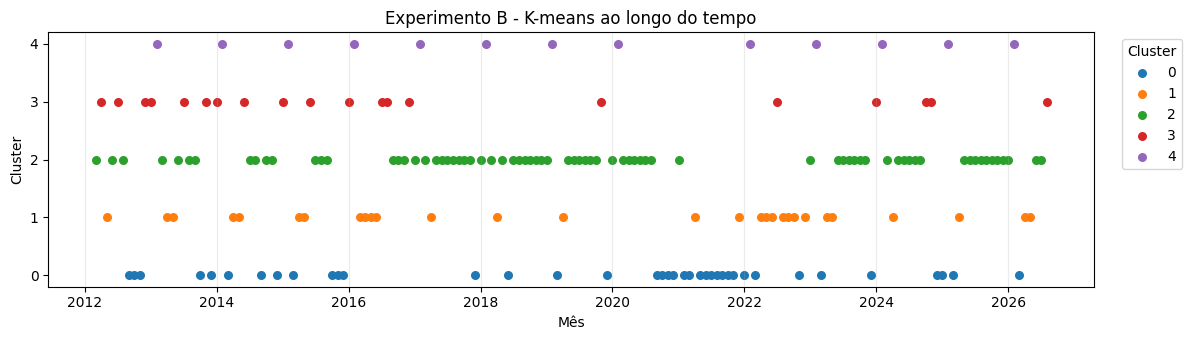

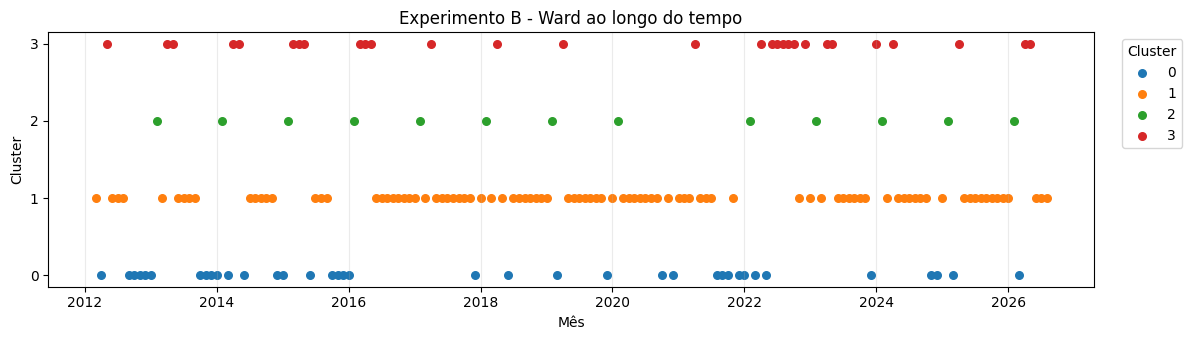

Casos divergentes K-means:


,Regime_Inflacao,IPCA,Cluster,Regime_predominante_no_cluster,IPCA_Transportes,IPCA Alimentação_bebidas,IPCA_Saúde_cuidados_pessoais,IPCA_Vestuário
Date,,,,,,,,
2012-03-01,Deflação,-0.08,2,Meta / Estável,0.16,0.25,0.38,-0.61
2012-05-01,Meta / Estável,0.48,1,Alta / Acima da Meta,-0.58,0.73,0.66,0.89
2012-06-01,Deflação,-0.31,2,Meta / Estável,-1.18,0.68,0.38,0.39
2012-07-01,Meta / Estável,0.06,3,Alta / Acima da Meta,-0.03,0.91,0.36,0.04
2013-02-01,Alta / Acima da Meta,0.63,4,Meta / Estável,0.81,1.45,0.65,0.55
2013-04-01,Meta / Estável,0.23,1,Alta / Acima da Meta,-0.19,0.96,1.28,0.65
2013-09-01,Alta / Acima da Meta,0.61,2,Meta / Estável,0.44,0.14,0.46,0.63
2015-02-01,Alta / Acima da Meta,0.59,4,Meta / Estável,2.20,0.81,0.60,-0.60
2016-09-01,Deflação,-0.04,2,Meta / Estável,-0.10,-0.29,0.33,0.43


Casos divergentes Ward:


,Regime_Inflacao,IPCA,Cluster,Regime_predominante_no_cluster,IPCA_Transportes,IPCA Alimentação_bebidas,IPCA_Saúde_cuidados_pessoais,IPCA_Vestuário
Date,,,,,,,,
2012-03-01,Deflação,-0.08,1,Meta / Estável,0.16,0.25,0.38,-0.61
2012-05-01,Meta / Estável,0.48,3,Alta / Acima da Meta,-0.58,0.73,0.66,0.89
2012-06-01,Deflação,-0.31,1,Meta / Estável,-1.18,0.68,0.38,0.39
2013-02-01,Alta / Acima da Meta,0.63,2,Meta / Estável,0.81,1.45,0.65,0.55
2013-04-01,Meta / Estável,0.23,3,Alta / Acima da Meta,-0.19,0.96,1.28,0.65
2013-05-01,Meta / Estável,0.23,3,Alta / Acima da Meta,-0.25,0.31,0.94,0.84
2013-09-01,Alta / Acima da Meta,0.61,1,Meta / Estável,0.44,0.14,0.46,0.63
2014-09-01,Alta / Acima da Meta,0.66,1,Meta / Estável,0.63,0.78,0.33,0.57
2016-09-01,Deflação,-0.04,1,Meta / Estável,-0.10,-0.29,0.33,0.43


,Modelo,K,Silhouette,Calinski_Harabasz,Davies_Bouldin,ARI_Regime,NMI_Regime
0,K-means,5,0.249,40.100,1.283,0.152,0.211
1,Hierárquico Ward,4,0.235,37.587,1.394,0.071,0.133


ARI K-means × Ward = 0.609


In [19]:
referencia_b = df.set_index("Date").loc[base_b.index, ["IPCA", "Regime_Inflacao"]].copy()
k_escolhido_b = 5
k_hierarquico_b = 4
analise_b = executar_analise_completa(
    "Experimento B", base_b, referencia_b, k_escolhido_b, k_hierarquico_b
)
base_b_padronizada = analise_b["base_padronizada"]
projecao_b = analise_b["projecao"]
resultados_kmeans_b = analise_b["resultados_kmeans"]
resultados_hierarquico_b = analise_b["resultados_hierarquico"]
clusters_kmeans_b = analise_b["clusters_kmeans"]
clusters_hierarquico_b = analise_b["clusters_hierarquico"]
tabela_final_b = analise_b["tabela_final"]